# Load Model and Data

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch 
from dreamerv4uwm.datasets import ShardedHDF5Dataset
from dreamerv4uwm.models.utils import load_tokenizer
from dreamerv4uwm.models.utils import load_denoiser
# DATA_PATH = "/home/mim-server/datasets/soar_data_sharded"
# DATA_PATH = "/home/mim-server/datasets/Finger/H5/combined"
DATA_PATH = "/home/mim-server/datasets/pushT/shareded-demo/"
DATA_PATH = "/home/mim-server/datasets/pushT/synthetic-reward/"
# DATA_PATH = "/media/mim-server/Volume1/lewm/sharded/cube/"
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
resolution = (256, 256)

In [3]:
from hydra import initialize, compose
from omegaconf import OmegaConf
with initialize(version_base=None, config_path="../scripts/config"):
    cfg = compose(config_name="dynamics/pushT.yaml")
    # cfg = compose(config_name="dynamics/lewm-cubes.yaml")

/home/mim-server/miniconda3/envs/dreamerv4/lib/python3.11/site-packages/hydra/_internal/defaults_list.py:251: UserWarning: In 'dynamics/pushT.yaml': Defaults list is missing `_self_`. See https://hydra.cc/docs/1.2/upgrades/1.0_to_1.1/default_composition_order for more information
  warnings.warn(msg, UserWarning)


In [4]:
# dynamics_ckpt = "/home/mim-server/projects/rooholla/dreamerV4-UWM/checkpoints/dynamics/pushT/no-shortcuts/all-2x-temporal-485204.pt"
dynamics_ckpt = "/home/mim-server/projects/rooholla/dreamerV4-UWM/checkpoints/dynamics/pushT/final/joint-model/v1/432360.pt"
# dynamics_ckpt = "/home/mim-server/projects/rooholla/dreamerV4-UWM/checkpoints/dynamics/lewm-cubes/joint/250000.pt"

In [5]:
tokenizer_ckpt="/home/mim-server/projects/rooholla/dreamerV4-UWM/checkpoints/tokenizer_ckpts/pushT.pt"
cfg.dynamics_ckpt = dynamics_ckpt
cfg.tokenizer_ckpt=tokenizer_ckpt
denoiser = load_denoiser(cfg, device, max_num_forward_steps=300)
tokenizer = load_tokenizer(cfg, device, max_num_forward_steps=300)
tokenizer = tokenizer.eval().cuda()
denoiser = denoiser.eval().cuda()

In [6]:
import mediapy
from torch.nn.functional import interpolate

dataset = ShardedHDF5Dataset(
        data_dir=DATA_PATH,
        window_size=96,
        stride=1,
        split='train',
        train_fraction=0.9,
        split_seed=123,
    )

# Arbitrary index into that episode
batch = dataset[torch.randint(len(dataset), (1,)).item()]
# imgs = batch["image"][:,[2, 1, 0], :, :]  # (T, C, H, W)
imgs = batch["image"]  # (T, C, H, W)
actions = batch["action"][:,:cfg.denoiser.n_actions]  # (1, T, N_lat, D_lat)
# actions=torch.zeros_like(actions)
imgs = interpolate(imgs, resolution).to(device=device)[None] # resize to tokenizer resolution

with torch.no_grad():
    with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
        latents = tokenizer.encode(imgs)
        imgs_recon = tokenizer.decode(latents)

from mediapy import show_video
def plotVideo(video):
    imgs = video.cpu().permute(0,2,3,1).to(torch.float32).numpy()*255
    imgs = imgs.astype('uint8')
    mediapy.show_video(imgs, fps=10)

plotVideo(imgs_recon[0])
plotVideo(imgs[0])

Train split: 5400 windows from 5400 episodes


This browser does not support the video tag.


This browser does not support the video tag.


In [7]:
len(dataset)

5400

In [8]:
from dreamerv4uwm.sampling import unified_flowmatching_sampler
import matplotlib.pyplot as plt

def plotSnapshots(video, n_frames=5, border_width=2, figsize=None):
    """Plot n_frames evenly-spaced snapshots from a video tensor, separated by black borders.
    
    Args:
        video: (T, C, H, W) tensor with values in [0, 1].
        n_frames: number of frames to sample.
        border_width: width of black separator lines in pixels.
    """
    import numpy as np
    T = video.shape[0]
    indices = np.linspace(0, T - 1, n_frames, dtype=int)
    frames = video[indices].cpu().permute(0, 2, 3, 1).to(torch.float32).numpy()  # (n, H, W, C)
    frames = np.clip(frames * 255, 0, 255).astype(np.uint8)
    H, W, C = frames.shape[1], frames.shape[2], frames.shape[3]
    border = np.zeros((H, border_width, C), dtype=np.uint8)
    parts = []
    for i, f in enumerate(frames):
        if i > 0:
            parts.append(border)
        parts.append(f)
    strip = np.concatenate(parts, axis=1)
    if figsize is None:
        figsize = (n_frames * 3, 3)
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    ax.imshow(strip)
    ax.axis('off')
    plt.tight_layout()
    plt.show()

def plotActions(actions, figsize=None):
    import numpy as np
    act = actions.cpu().float().numpy() if hasattr(actions, 'cpu') else np.array(actions)
    # if figsize is None:
    figsize = (3 , 3)
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    ax.plot(act[:, 0], linewidth=3, label=r'$\mathbf{v_x}$')
    ax.plot(act[:, 1], linewidth=3, label=r'$\mathbf{v_y}$')
    ax.set_ylim(-1., 1.)
    ax.set_xticklabels([])
    ax.tick_params(axis='x', length=0)
    ax.tick_params(axis='y', labelsize=16)
    for label in ax.get_yticklabels():
        label.set_fontweight('bold')
    ax.legend(fontsize=16)
    plt.tight_layout()
    plt.show()

In [9]:
num_pred_steps = 32
num_diffusion_steps = 16
T_ctx = 24
latents_ctx = latents[:, :T_ctx, ...].clone()


This browser does not support the video tag.


This browser does not support the video tag.


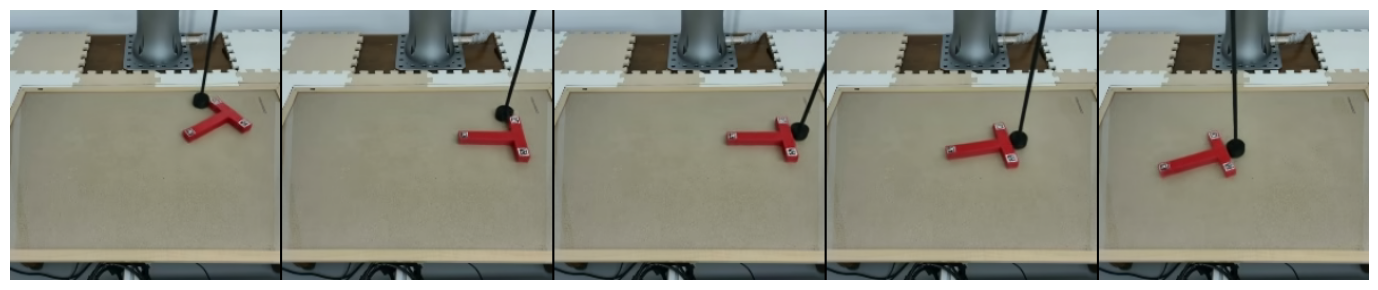

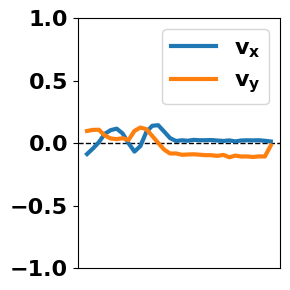

In [10]:
ctx_actions_policy = actions[:T_ctx][None].cuda()  # (1, T_ctx, n_act)
with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
    pred_obs_pol, pred_act_pol = unified_flowmatching_sampler(
        denoiser, latents_ctx, mode='policy',
        ctx_actions=ctx_actions_policy,
        num_pred_steps=num_pred_steps,
        num_diffusion_steps=num_diffusion_steps,
    )
    with torch.no_grad():
        img_pred_pol = tokenizer.decode(pred_obs_pol)

plotVideo(img_pred_pol[0].to(torch.float32))
plotVideo(imgs[0,0:T_ctx].to(torch.float32))
plotSnapshots(img_pred_pol[0].to(torch.float32))
pr_act = pred_act_pol[0].cpu().float().numpy()
plotActions(pr_act)

In [10]:
import math
import torch
from dreamerv4uwm.sampling import get_noise_index


@torch.no_grad()
def policy_sampler(
    denoiser,
    ctx_latents,            # (B, T_ctx, N_lat, D_lat) — clean context obs
    ctx_actions,            # (B, T_ctx, n_act)        — clean context actions
    num_pred_steps=1,
    num_diffusion_steps=4,  # power of two
    context_cond_tau=0.9,
    action_noise_std=1.0,
):
    """Simplified policy-mode Euler sampler (single call, no shortcut, no cache).

    Context obs and actions are conditioned (slightly noised at tau_cond);
    future obs latents and actions are jointly denoised from pure noise.
    """
    assert (num_diffusion_steps & (num_diffusion_steps - 1)) == 0, \
        "num_diffusion_steps must be a power of two"

    device = ctx_latents.device
    dtype  = ctx_latents.dtype
    B, T_ctx, N_lat, D_lat = ctx_latents.shape
    T_total = T_ctx + num_pred_steps
    n_act = ctx_actions.shape[-1]
    ctx_actions = ctx_actions.to(device=device, dtype=dtype)

    num_noise_levels  = denoiser.cfg.denoiser.num_noise_levels
    step_index_tensor = torch.zeros((B, T_total), dtype=torch.long, device=device)  # flowmatching: finest step
    tau_cond_idx      = get_noise_index(context_cond_tau, num_noise_levels)
    stride            = num_noise_levels // num_diffusion_steps
    step_size         = 1.0 / num_diffusion_steps

    # obs init: future = pure noise, context = slightly noised clean
    z = torch.randn(B, T_total, N_lat, D_lat, device=device, dtype=dtype)
    z[:, :T_ctx] = (1.0 - context_cond_tau) * torch.randn_like(ctx_latents) + context_cond_tau * ctx_latents

    # action init: same scheme
    z_act = action_noise_std * torch.randn(B, T_total, n_act, device=device, dtype=dtype)
    z_act[:, :T_ctx] = (
        (1.0 - context_cond_tau) * action_noise_std * torch.randn_like(ctx_actions)
        + context_cond_tau * ctx_actions
    )

    for k in range(num_diffusion_steps):
        tau_idx = k * stride
        tau     = tau_idx / float(num_noise_levels)

        obs_sigma_idx = torch.full((B, T_total), tau_idx, dtype=torch.long, device=device)
        act_sigma_idx = torch.full((B, T_total), tau_idx, dtype=torch.long, device=device)
        obs_sigma_idx[:, :T_ctx] = tau_cond_idx
        act_sigma_idx[:, :T_ctx] = tau_cond_idx

        z_hat, act_hat = denoiser(
            noisy_act    = z_act,
            noisy_obs    = z,
            obs_sigma_idx= obs_sigma_idx,
            obs_step_idx = step_index_tensor,
            act_sigma_idx= act_sigma_idx,
            act_step_idx = step_index_tensor,
        )
        act_hat = act_hat.squeeze(-2)

        denom = max(1.0 - tau, 1e-5)
        v_obs = (z_hat   - z    ) / denom
        v_act = (act_hat - z_act) / denom
        z    [:, T_ctx:] = z    [:, T_ctx:] + (v_obs * step_size)[:, T_ctx:]
        z_act[:, T_ctx:] = z_act[:, T_ctx:] + (v_act * step_size)[:, T_ctx:]

    return z[:, T_ctx:], z_act[:, T_ctx:]


@torch.no_grad()
def rolling_window_policy_sampler(
    denoiser,
    init_latents,           # (B, T_init, N_lat, D_lat) — initial obs context (e.g. real history)
    init_actions,           # (B, T_init, n_act)        — initial action context
    total_pred_steps,       # total #frames+actions to generate beyond the init context
    chunk_size=4,           # k: #frames generated per sampler call
    max_context=24,         # cap on #frames fed to the model on each call
    num_diffusion_steps=4,
    context_cond_tau=0.9,
    action_noise_std=1.0,
):
    """Roll the policy sampler forward k frames at a time, growing a long
    trajectory while keeping the model's input context truncated.

    Each iteration:
      1. Take the most-recent `max_context` (obs, action) pairs as context.
      2. Sample `min(chunk_size, remaining)` new (obs, action) pairs jointly.
      3. Append them to the rolling window; older frames fall off implicitly
         on the next iteration.

    Returns
    -------
    pred_obs : (B, total_pred_steps, N_lat, D_lat) — only the newly generated frames
    pred_act : (B, total_pred_steps, n_act)
    """
    device = init_latents.device
    dtype  = init_latents.dtype

    obs_window = init_latents.clone()
    act_window = init_actions.clone().to(device=device, dtype=dtype)

    pred_obs_chunks, pred_act_chunks = [], []
    remaining = total_pred_steps
    while remaining > 0:
        k = min(chunk_size, remaining)

        ctx_obs = obs_window[:, -max_context:]
        ctx_act = act_window[:, -max_context:]

        new_obs, new_act = policy_sampler(
            denoiser,
            ctx_latents        = ctx_obs,
            ctx_actions        = ctx_act,
            num_pred_steps     = k,
            num_diffusion_steps= num_diffusion_steps,
            context_cond_tau   = context_cond_tau,
            action_noise_std   = action_noise_std,
        )

        pred_obs_chunks.append(new_obs)
        pred_act_chunks.append(new_act)
        obs_window = torch.cat([obs_window, new_obs], dim=1)
        act_window = torch.cat([act_window, new_act], dim=1)
        remaining -= k

    return torch.cat(pred_obs_chunks, dim=1), torch.cat(pred_act_chunks, dim=1)

This browser does not support the video tag.


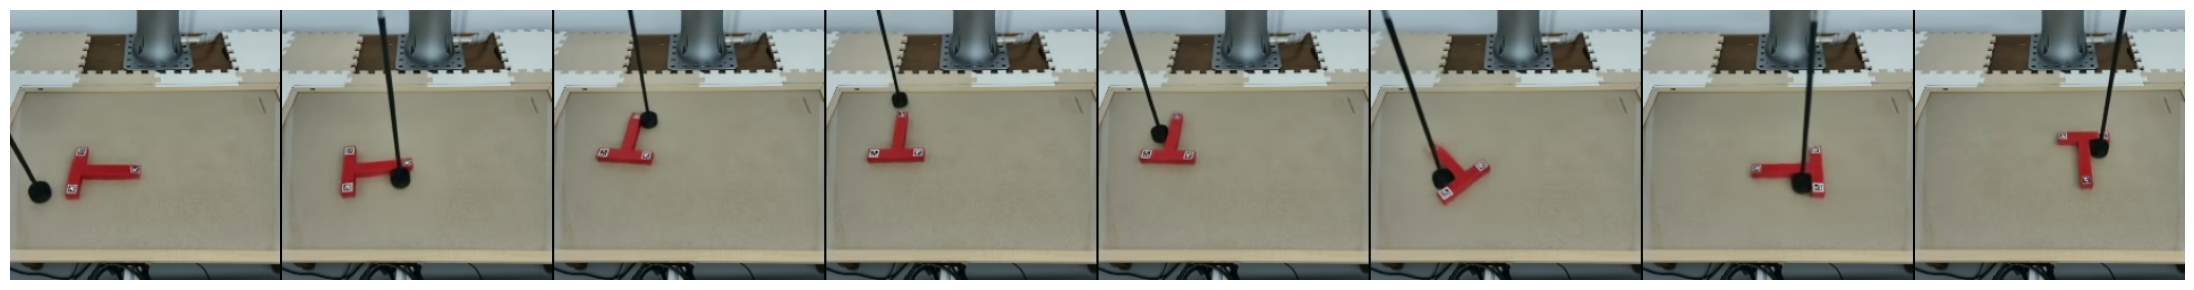

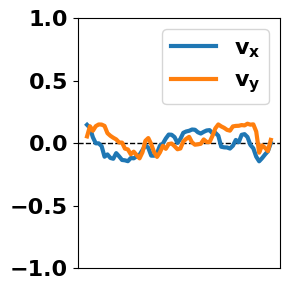

In [11]:
# Rolling-window rollout: generate a long horizon while keeping model context bounded.
T_init           = 8       # frames of real history to seed with
total_pred_steps = 64      # total frames to roll out
chunk_size       = 8       # k: frames generated per sampler call
max_context      = 24      # cap on frames fed to the model

init_latents = latents[:, :T_init, ...].clone()
init_actions = actions[:T_init][None].cuda()

with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
    roll_obs, roll_act = rolling_window_policy_sampler(
        denoiser,
        init_latents       = init_latents,
        init_actions       = init_actions,
        total_pred_steps   = total_pred_steps,
        chunk_size         = chunk_size,
        max_context        = max_context,
        num_diffusion_steps= num_diffusion_steps,
    )
    with torch.no_grad():
        roll_imgs = tokenizer.decode(roll_obs)

plotVideo(roll_imgs[0].to(torch.float32))
plotSnapshots(roll_imgs[0].to(torch.float32), n_frames=8)
plotActions(roll_act[0].cpu().float().numpy())

In [12]:
@torch.no_grad()
def progressive_rolling_sampler(
    denoiser,
    init_latents,           # (B, T_init, N_lat, D_lat) — clean obs context
    init_actions,           # (B, T_init, n_act)        — clean action context
    total_pred_steps,       # frames to emit
    window_size=8,          # F: rolling window size = #steps to fully clean one frame
    context_size=8,         # C: clean prefix kept in front of the window (0 = pure paper algo)
    context_cond_tau=0.9,
    action_noise_std=1.0,
):
    """Progressive autoregressive rolling sampler.

    Adapts 'Progressive Autoregressive Video Diffusion Models' (Xie et al., 2024,
    https://arxiv.org/abs/2410.08151) to the UWM joint obs+action flowmatching
    denoiser. Each main-loop iteration:
        1. All F window frames are denoised by one quantum (dt = 1/F).
        2. The frontmost frame reaches tau=1 (clean) and is emitted.
        3. The window shifts left; a fresh pure-noise frame is appended at the back.
        4. The clean prefix (length C) gains the emitted frame and drops its oldest.

    A short F-1 step warmup grows the window from 1 to F so the staircase noise
    schedule is built in place rather than faked from samples.

    Note: this codebase uses tau=1 == clean, tau=0 == pure noise (opposite of the
    paper). The staircase is expressed in this convention throughout.
    """
    F, C = window_size, context_size
    device = init_latents.device
    dtype  = init_latents.dtype
    B, T_init, N_lat, D_lat = init_latents.shape
    n_act = init_actions.shape[-1]
    init_actions = init_actions.to(device=device, dtype=dtype)

    assert C <= T_init, f"context_size C={C} cannot exceed init context T_init={T_init}"
    N = denoiser.cfg.denoiser.num_noise_levels
    assert N % F == 0, "num_noise_levels must be divisible by window_size for an exact stride"

    stride       = N // F          # quanta advanced per Euler step
    step_size    = 1.0 / F         # Euler dt
    tau_cond_idx = get_noise_index(context_cond_tau, N)

    # always-clean prefix (re-noised to tau_cond on every forward)
    prefix_obs = init_latents[:, -C:].clone() if C > 0 else None
    prefix_act = init_actions[:, -C:].clone() if C > 0 else None

    # rolling window starts with a single pure-noise frame; warmup grows it to F.
    z_obs   = torch.randn(B, 1, N_lat, D_lat, device=device, dtype=dtype)
    z_act   = action_noise_std * torch.randn(B, 1, n_act, device=device, dtype=dtype)
    tau_idx = torch.zeros((B, 1), dtype=torch.long, device=device)

    def _fresh_noise():
        return (
            torch.randn(B, 1, N_lat, D_lat, device=device, dtype=dtype),
            action_noise_std * torch.randn(B, 1, n_act, device=device, dtype=dtype),
            torch.zeros((B, 1), dtype=torch.long, device=device),
        )

    pred_obs_buf, pred_act_buf = [], []

    while len(pred_obs_buf) < total_pred_steps:
        cur_F = z_obs.shape[1]

        # ---- assemble input: noised clean prefix + window ----
        if C > 0:
            p_obs_in = (1.0 - context_cond_tau) * torch.randn_like(prefix_obs) + context_cond_tau * prefix_obs
            p_act_in = ((1.0 - context_cond_tau) * action_noise_std * torch.randn_like(prefix_act)
                        + context_cond_tau * prefix_act)
            obs_in = torch.cat([p_obs_in, z_obs], dim=1)
            act_in = torch.cat([p_act_in, z_act], dim=1)
            prefix_sigma = torch.full((B, C), tau_cond_idx, dtype=torch.long, device=device)
            sigma_idx = torch.cat([prefix_sigma, tau_idx], dim=1)
        else:
            obs_in, act_in, sigma_idx = z_obs, z_act, tau_idx

        step_idx_tensor = torch.zeros((B, C + cur_F), dtype=torch.long, device=device)

        z_hat, act_hat = denoiser(
            noisy_act    = act_in,
            noisy_obs    = obs_in,
            obs_sigma_idx= sigma_idx,
            obs_step_idx = step_idx_tensor,
            act_sigma_idx= sigma_idx,
            act_step_idx = step_idx_tensor,
        )
        act_hat = act_hat.squeeze(-2)
        z_hat_w, act_hat_w = z_hat[:, C:], act_hat[:, C:]

        # ---- per-frame Euler step on the window ----
        tau_cont = tau_idx.float() / float(N)              # (B, cur_F)
        denom    = (1.0 - tau_cont).clamp_min(1e-5)         # (B, cur_F)
        z_obs = z_obs + (z_hat_w   - z_obs) / denom[..., None, None] * step_size
        z_act = z_act + (act_hat_w - z_act) / denom[..., None]       * step_size
        tau_idx = tau_idx + stride

        if cur_F < F:
            # warmup: append a fresh noise frame at the back, no emission
            new_o, new_a, new_t = _fresh_noise()
            z_obs   = torch.cat([z_obs,   new_o], dim=1)
            z_act   = torch.cat([z_act,   new_a], dim=1)
            tau_idx = torch.cat([tau_idx, new_t], dim=1)
        else:
            # main: emit front, shift left, append fresh noise at back
            emit_obs, emit_act = z_obs[:, :1], z_act[:, :1]
            pred_obs_buf.append(emit_obs)
            pred_act_buf.append(emit_act)

            new_o, new_a, new_t = _fresh_noise()
            z_obs   = torch.cat([z_obs[:, 1:],   new_o], dim=1)
            z_act   = torch.cat([z_act[:, 1:],   new_a], dim=1)
            tau_idx = torch.cat([tau_idx[:, 1:], new_t], dim=1)

            if C > 0:
                prefix_obs = torch.cat([prefix_obs[:, 1:], emit_obs], dim=1)
                prefix_act = torch.cat([prefix_act[:, 1:], emit_act], dim=1)

    return torch.cat(pred_obs_buf, dim=1), torch.cat(pred_act_buf, dim=1)

This browser does not support the video tag.


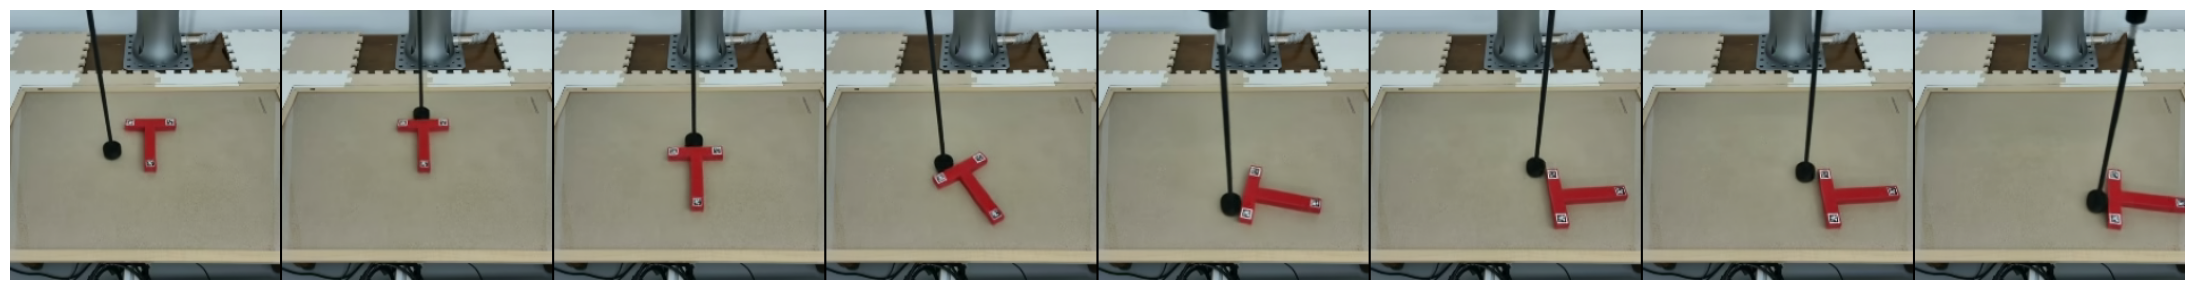

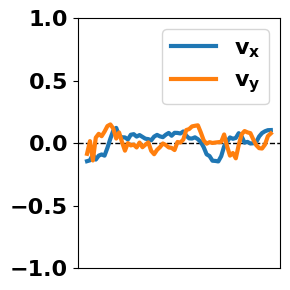

In [13]:
# Progressive autoregressive rollout: per-frame staircase noise schedule.
T_init           = 64       # frames of real history to seed with
total_pred_steps = 64      # frames to emit
window_size      = 16       # F: per-frame staircase depth (= #steps to clean one frame)
context_size     = 2       # C: clean overlap-conditioning prefix

init_latents = latents[:, :T_init, ...].clone()
init_actions = actions[:T_init][None].cuda()

with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
    prog_obs, prog_act = progressive_rolling_sampler(
        denoiser,
        init_latents     = init_latents,
        init_actions     = init_actions,
        total_pred_steps = total_pred_steps,
        window_size      = window_size,
        context_size     = context_size,
    )
    with torch.no_grad():
        prog_imgs = tokenizer.decode(prog_obs)

plotVideo(prog_imgs[0].to(torch.float32))
plotSnapshots(prog_imgs[0].to(torch.float32), n_frames=8)
plotActions(prog_act[0].cpu().float().numpy())

In [14]:
@torch.no_grad()
def hybrid_progressive_sampler(
    denoiser,
    init_latents,           # (B, T_init, N_lat, D_lat) — clean prefix from real demo
    init_actions,           # (B, T_init, n_act)        — clean prefix actions
    demo_actions,           # (B, demo_len, n_act)      — clean demo actions to pin for demo emissions
    play_pred_steps,        # number of play emissions after the demo
    window_size=8,          # F: rolling window size = staircase depth
    context_size=8,         # C: clean overlap-conditioning prefix
    context_cond_tau=0.9,
    action_noise_std=1.0,
):
    """Hybrid demo->play progressive autoregressive sampler.

    Same staircase pipeline as `progressive_rolling_sampler`, but each window
    slot has a per-position 'mode':
      - demo: action sigma held at clean_idx and the action *value* pinned to
        the supplied clean demo action throughout; only the obs is denoised
        through the staircase. Result: WM-manifold state given a real action.
      - play: action sigma follows the staircase; obs and action are denoised
        jointly. Result: full WM rollout.

    The first `demo_len` (= demo_actions.shape[1]) emissions are demo; the
    remaining `play_pred_steps` are play. Both halves go through the SAME obs
    pipeline so a downstream discriminator can't latch on to pipeline
    statistics — the only difference is which actions condition the dynamics.

    Returns
    -------
    pred_obs : (B, demo_len + play_pred_steps, N_lat, D_lat)
    pred_act : (B, demo_len + play_pred_steps, n_act)
    labels   : (demo_len + play_pred_steps,) long tensor — 1 = demo, 0 = play
    """
    F, C = window_size, context_size
    device, dtype = init_latents.device, init_latents.dtype
    B, T_init, N_lat, D_lat = init_latents.shape
    n_act = init_actions.shape[-1]
    init_actions = init_actions.to(device=device, dtype=dtype)
    demo_actions = demo_actions.to(device=device, dtype=dtype)
    demo_len = demo_actions.shape[1]
    L = demo_len + play_pred_steps

    assert C <= T_init, f"context_size C={C} cannot exceed init context T_init={T_init}"
    N = denoiser.cfg.denoiser.num_noise_levels
    assert N % F == 0, "num_noise_levels must be divisible by window_size"

    stride       = N // F
    step_size    = 1.0 / F
    tau_cond_idx = get_noise_index(context_cond_tau, N)
    clean_idx    = N - 1

    # always-clean prefix from the real demo (re-noised to tau_cond on every fwd)
    prefix_obs = init_latents[:, -C:].clone() if C > 0 else None
    prefix_act = init_actions[:, -C:].clone() if C > 0 else None

    # per-emit schedule: True = demo slot, False = play slot
    is_demo_emit = [True] * demo_len + [False] * play_pred_steps  # length L

    next_emit = [0]   # boxed for closure mutation
    def _make_slot():
        i = next_emit[0]
        is_demo = is_demo_emit[i]
        z_o = torch.randn(B, 1, N_lat, D_lat, device=device, dtype=dtype)
        if is_demo:
            z_a = demo_actions[:, i:i + 1].clone()
        else:
            z_a = action_noise_std * torch.randn(B, 1, n_act, device=device, dtype=dtype)
        t = torch.zeros((B, 1), dtype=torch.long, device=device)
        next_emit[0] += 1
        return z_o, z_a, t, is_demo

    # initial window: a single slot for emission #0
    z_obs, z_act, tau_idx, is_d = _make_slot()
    window_demo = [is_d]

    pred_obs_buf, pred_act_buf, label_buf = [], [], []

    while len(pred_obs_buf) < L:
        cur_F = z_obs.shape[1]
        demo_mask = torch.tensor(window_demo, dtype=torch.bool, device=device)  # (cur_F,)

        # ---- assemble model input ----
        if C > 0:
            p_obs_in = (1.0 - context_cond_tau) * torch.randn_like(prefix_obs) + context_cond_tau * prefix_obs
            p_act_in = ((1.0 - context_cond_tau) * action_noise_std * torch.randn_like(prefix_act)
                        + context_cond_tau * prefix_act)
            obs_in = torch.cat([p_obs_in, z_obs], dim=1)
            act_in = torch.cat([p_act_in, z_act], dim=1)
            prefix_sigma = torch.full((B, C), tau_cond_idx, dtype=torch.long, device=device)
            obs_sigma_idx = torch.cat([prefix_sigma, tau_idx], dim=1)
        else:
            obs_in, act_in, obs_sigma_idx = z_obs, z_act, tau_idx

        # action sigma: staircase for play, clean_idx for demo
        win_act_sigma = torch.where(
            demo_mask.unsqueeze(0).expand(B, -1),
            torch.full_like(tau_idx, clean_idx),
            tau_idx,
        )
        act_sigma_idx = torch.cat([prefix_sigma, win_act_sigma], dim=1) if C > 0 else win_act_sigma

        step_idx_tensor = torch.zeros((B, C + cur_F), dtype=torch.long, device=device)

        z_hat, act_hat = denoiser(
            noisy_act    = act_in,
            noisy_obs    = obs_in,
            obs_sigma_idx= obs_sigma_idx,
            obs_step_idx = step_idx_tensor,
            act_sigma_idx= act_sigma_idx,
            act_step_idx = step_idx_tensor,
        )
        act_hat = act_hat.squeeze(-2)
        z_hat_w, act_hat_w = z_hat[:, C:], act_hat[:, C:]

        # ---- per-frame Euler step on obs (always); on actions only for play slots ----
        tau_cont = tau_idx.float() / float(N)               # (B, cur_F)
        denom    = (1.0 - tau_cont).clamp_min(1e-5)          # (B, cur_F)
        z_obs = z_obs + (z_hat_w - z_obs) / denom[..., None, None] * step_size

        play_mask_f = (~demo_mask).to(dtype).view(1, cur_F, 1)
        z_act = z_act + (act_hat_w - z_act) / denom[..., None] * step_size * play_mask_f
        # demo slots: action stays pinned to its clean value

        tau_idx = tau_idx + stride

        # ---- emit if front frame is now clean ----
        if int(tau_idx[0, 0].item()) >= N:
            emit_obs, emit_act = z_obs[:, :1], z_act[:, :1]
            pred_obs_buf.append(emit_obs)
            pred_act_buf.append(emit_act)
            label_buf.append(int(window_demo[0]))
            z_obs, z_act, tau_idx = z_obs[:, 1:], z_act[:, 1:], tau_idx[:, 1:]
            window_demo = window_demo[1:]
            if C > 0:
                prefix_obs = torch.cat([prefix_obs[:, 1:], emit_obs], dim=1)
                prefix_act = torch.cat([prefix_act[:, 1:], emit_act], dim=1)

        # ---- append a fresh slot at back if window has room and more emissions are scheduled ----
        if z_obs.shape[1] < F and next_emit[0] < L:
            new_o, new_a, new_t, new_d = _make_slot()
            z_obs   = torch.cat([z_obs,   new_o], dim=1)
            z_act   = torch.cat([z_act,   new_a], dim=1)
            tau_idx = torch.cat([tau_idx, new_t], dim=1)
            window_demo.append(new_d)

    pred_obs = torch.cat(pred_obs_buf, dim=1)
    pred_act = torch.cat(pred_act_buf, dim=1)
    labels   = torch.tensor(label_buf, dtype=torch.long, device=device)
    return pred_obs, pred_act, labels

In [15]:
from PIL import Image, ImageDraw, ImageFont
import numpy as np


def plotLabeledVideo(video, labels, fps=10,
                     demo_color=(40, 175, 80), play_color=(220, 60, 60)):
    """Show a video with a per-frame DEMO/PLAY label bar across the top.

    Args:
        video : (T, C, H, W) torch tensor in [0, 1], or (T, H, W, C) uint8 np array.
        labels: (T,) tensor or array; 1 = demo, 0 = play.
    """
    if torch.is_tensor(video):
        imgs = video.cpu().permute(0, 2, 3, 1).to(torch.float32).numpy() * 255
        imgs = np.clip(imgs, 0, 255).astype(np.uint8)
    else:
        imgs = np.asarray(video, dtype=np.uint8)
    if torch.is_tensor(labels):
        labels = labels.cpu().tolist()
    else:
        labels = list(labels)

    T, H, W = imgs.shape[:3]
    bar_h = max(20, H // 12)
    try:
        font = ImageFont.truetype(
            "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf",
            max(12, bar_h - 6),
        )
    except OSError:
        font = ImageFont.load_default()

    out_frames = []
    for i, frame in enumerate(imgs):
        is_demo = bool(labels[i])
        color = demo_color if is_demo else play_color
        text = f"DEMO  ({i})" if is_demo else f"PLAY  ({i})"
        img = Image.fromarray(frame)
        draw = ImageDraw.Draw(img)
        draw.rectangle([(0, 0), (W, bar_h)], fill=color)
        bbox = draw.textbbox((0, 0), text, font=font)
        tw, th = bbox[2] - bbox[0], bbox[3] - bbox[1]
        draw.text(((W - tw) / 2, (bar_h - th) / 2 - 2), text, fill=(255, 255, 255), font=font)
        out_frames.append(np.array(img))

    mediapy.show_video(np.stack(out_frames, axis=0), fps=fps)

This browser does not support the video tag.


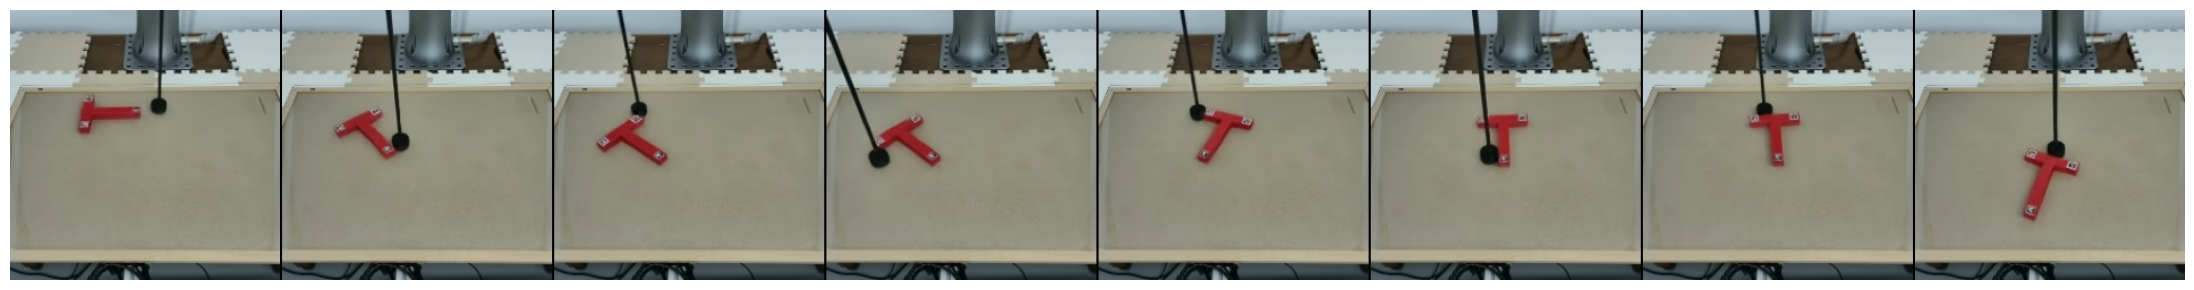

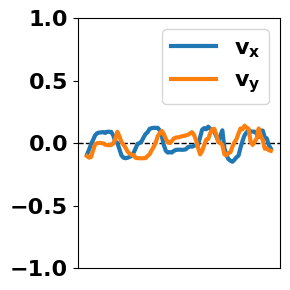

In [ ]:
# Hybrid demo->play snippet generation with per-frame labels.
T_init        = 4         # frames of real demo as the always-clean prefix
demo_len      = 68        # WM-projected demo emissions (real demo actions, WM-denoised states)
play_pred     = 32        # WM-rolled play emissions (joint denoising)
window_size   = 8
context_size  = 4

init_latents = latents[:, :T_init, ...].clone()
init_actions = actions[:T_init][None].cuda()
demo_actions = actions[T_init:T_init + demo_len][None].cuda()  # real demo actions to inject

with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
    hyb_obs, hyb_act, hyb_labels = hybrid_progressive_sampler(
        denoiser,
        init_latents     = init_latents,
        init_actions     = init_actions,
        demo_actions     = demo_actions,
        play_pred_steps  = play_pred,
        window_size      = window_size,
        context_size     = context_size,
    )
    with torch.no_grad():
        hyb_imgs = tokenizer.decode(hyb_obs)

plotLabeledVideo(hyb_imgs[0].to(torch.float32), hyb_labels)
plotSnapshots(hyb_imgs[0].to(torch.float32), n_frames=8)
plotActions(hyb_act[0].cpu().float().numpy())